In [1]:
import pandas as pd

# Load your TSV (with columns: id, document, label, label_type, text, label_indices)
df = pd.read_csv("dataset/claudette_all_merged.tsv", sep='\t')

# Expand so that each row has one category (for coloring)
rows = []
for _, row in df[df.label == 1].iterrows():
    for cat in eval(row['label_type']):  # e.g. ["USE", "DISCLOSE"]
        rows.append({'text': row['text'], 'category': cat})
plot_df = pd.DataFrame(rows)


In [2]:
plot_df

,text,category
0,by accessing or signing up to receive communic...,USE
1,you understand and agree that mozilla reserves...,CR
2,we may suspend or terminate your access to our...,TER
3,"except as required by law , mozilla and the in...",LTD
4,the collective liability of mozilla and the in...,LTD
...,...,...
2389,terminate your account or your access to the s...,TER
2390,monitor or review any content submitted by you...,CR
2391,monitor or review any content submitted by you...,TER
2392,"the company reserves the right , at its sole d...",CH


In [3]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-mpnet-base-v2')  # strong general-purpose encoder :contentReference[oaicite:4]{index=4}
texts = plot_df['text'].tolist()
embeddings = model.encode(texts, show_progress_bar=True, convert_to_numpy=True)

Batches:   0%|          | 0/75 [00:00<?, ?it/s]

In [4]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
emb_2d = tsne.fit_transform(embeddings)

/Users/erkanturan/CODE/TUM/PromptEngineering/.venv/lib/python3.11/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/Users/erkanturan/CODE/TUM/PromptEngineering/.venv/lib/python3.11/site-packages/threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenize

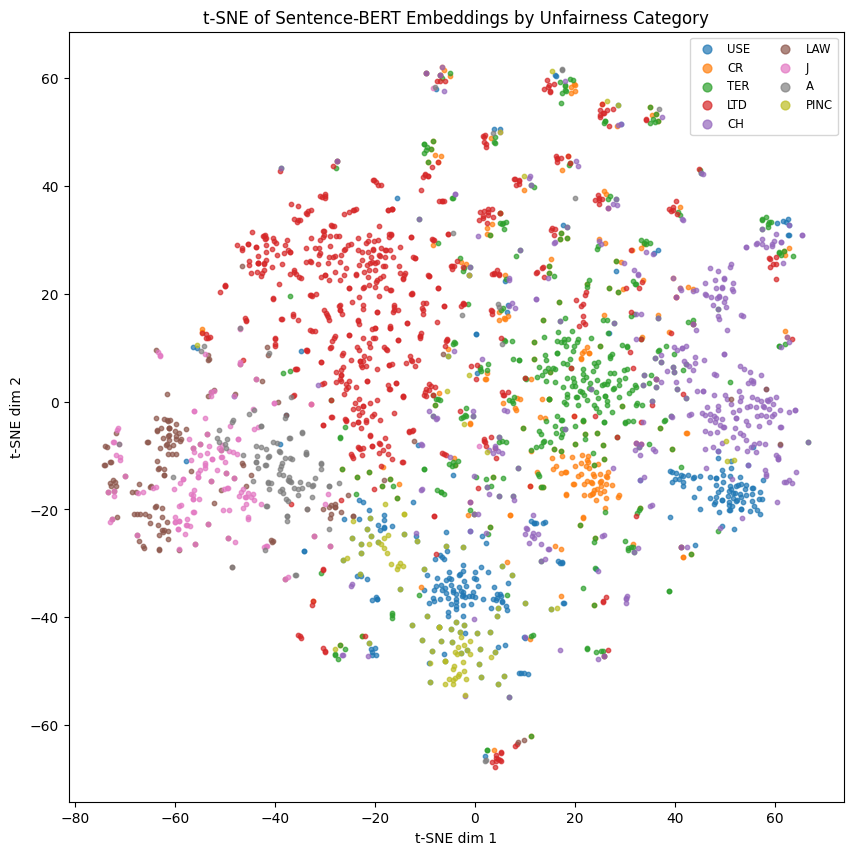

In [5]:
import matplotlib.pyplot as plt

plot_df['x'], plot_df['y'] = emb_2d[:,0], emb_2d[:,1]
categories = plot_df['category'].unique()

plt.figure(figsize=(10,10))
for cat in categories:
    subset = plot_df[plot_df['category']==cat]
    plt.scatter(subset['x'], subset['y'], label=cat, alpha=0.7, s=10)
plt.legend(markerscale=2, fontsize='small', ncol=2)
plt.title("t-SNE of Sentence-BERT Embeddings by Unfairness Category")
plt.xlabel("t-SNE dim 1")
plt.ylabel("t-SNE dim 2")
plt.show()